In [1]:
import os
import json
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [60]:

def ert(values: list[float]):
    total = 0
    n_suc = 0
    for v in values:
        if v < 100_000:
            n_suc += 1
        total += v
    if n_suc == 0:
        return float("inf")
    return total / n_suc


def get_config_ert(run_data):
    config_rt = defaultdict(list)

    for config in run_data['data']:
        cost, cid = config['cost'], str(config['config_id'])
        if cost != 1_000_000 and np.isfinite(cost):
            rt = config['additional_info']['evals']
            solved = config['additional_info']['hit_target']
            config_rt[cid].append(rt if solved else 100_000)
    return {key: (ert_) for key, rt in config_rt.items() 
            if len(rt) == 25 and np.isfinite(ert_:=ert(rt))}


def get_config_cost(run_data):
    config_cost = defaultdict(list)

    for config in run_data['data']:
        cost, cid = config['cost'], str(config['config_id'])
        config_cost[cid].append(cost)
    return config_cost



ert_data = {}
configs = {}
cost_data = {}
runs = {}
folders = os.listdir("data")
for folder in folders:
    if folder.endswith("FalseFalse"): continue
    run_key = os.listdir(os.path.join("data", folder))[0]
    run_history = os.path.join("data", folder, run_key,  "0/runhistory.json")
    with open(run_history) as f:
        run_data = json.load(f)
        fid = int(folder.split("BBOB_F")[1].split("_5D")[0])
        cost_data[fid] = get_config_cost(run_data)
        ert_data[fid] = get_config_ert(run_data)
        configs[fid] = run_data['configs']
        runs[fid] = run_data['data']

In [4]:
mean_costs = {
    fid: {ci: np.mean(c) 
          for ci, c in costs.items() if len(c) == 25}
    for fid, costs in cost_data.items()
}

In [21]:
from modcma import c_maes
import ioh


def get_best_config(cost_data):
    cmax = 1
    cid = None
    for ci, costs in cost_data.items():
        if len(costs) != 25: continue
        if (mcost:=np.mean(costs)) < cmax:
            cmax = mcost
            cid = ci
    return cid, cmax   


def get_topk(mean_cost_data, k = 5):
    confs = np.array(list(mean_cost_data.keys()))
    costs = np.array(list(mean_cost_data.values()))
    idx = np.argsort(costs)[:k]
    return confs[idx], costs[idx]
         

seed = 69
tuned_ert = []
start = 100
for fid in range(1, 25):
    print(fid, end=", ", flush=True)
    for cid, cost in zip(*get_topk(mean_costs[fid])):
        config = configs[fid][cid].copy()
        suc = 0
        rt = 0
        for iid in range(start, start+ 50):
            np.random.seed(seed + iid)
            c_maes.utils.set_seed(seed + iid)
            settings = c_maes.settings_from_dict(5, **config)   
            problem = ioh.get_problem(fid, iid, settings.dim)
            
            settings.budget = settings.dim * 10_000
            settings.target = problem.optimum.y + 1e-8
            es = c_maes.ModularCMAES(settings)
            es.run(problem)
            suc += problem.state.final_target_found
            rt  += problem.state.evaluations
        erti = float("inf") if suc == 0  else rt / suc
        tuned_ert.append((fid, str(cid), erti, suc))
print("done")
tuned_ert = pd.DataFrame(tuned_ert, columns=("fid", "cid", "ert", "sr"))
tuned_ert

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, done


,fid,cid,ert,sr
0,1,1303,186.080000,50
1,1,2382,190.560000,50
2,1,3560,185.880000,50
3,1,1534,188.880000,50
4,1,3895,204.560000,50
...,...,...,...,...
115,24,3003,473607.400000,5
116,24,3356,473607.400000,5
117,24,3110,474681.600000,5
118,24,3352,473607.400000,5


In [78]:
tuned_ert_min = tuned_ert.groupby("fid")['ert'].min().values

df_min = tuned_ert.iloc[tuned_ert.groupby("fid")['ert'].idxmin()]

configs_min = []
for fid in range(1, 25):
    row = df_min.query(f"fid == {fid}").iloc[0].to_dict()
    row['mean_cost'] = mean_costs[fid][row['cid']]
    row['smac_ert'] = round(ert_data[fid][row['cid']], 1)
    row['ert'] = round(row['ert'], 1)
    row.update(**configs[fid][row['cid']])
    configs_min.append(row)

configs5d = pd.DataFrame(configs_min)
configs5d.to_csv("configs_selected.csv", index=False)
configs5d

,fid,cid,ert,sr,mean_cost,smac_ert,active,elitist,lambda0,matrix_adaptation,...,mu0,orthogonal,repelling_restart,restart_strategy,sample_transformation,sampler,sequential_selection,ssa,threshold_convergence,weights
0,1,3560,185.9,50,0.001750,185.3,False,True,2,NONE,...,1,True,False,RESTART,SCALED_UNIFORM,SOBOL,False,CSA,False,EQUAL
1,2,1772,750.0,50,0.010599,795.3,True,True,1,SEPARABLE,...,1,False,False,NONE,CAUCHY,HALTON,False,PSR,True,DEFAULT
2,3,2282,13951.9,50,0.256131,44970.1,True,False,78,COVARIANCE,...,48,False,False,RESTART,LAPLACE,HALTON,False,TPA,False,DEFAULT
3,4,3623,51058.3,42,0.414946,55333.2,True,True,167,SEPARABLE,...,1,True,False,NONE,CAUCHY,UNIFORM,False,SA,False,EXPONENTIAL
4,5,1999,21.7,50,0.000290,17.5,False,False,6,CMSA,...,1,True,True,IPOP,GAUSSIAN,SOBOL,True,MXNES,True,DEFAULT
5,6,1644,756.8,50,0.007809,742.2,True,False,1,NATURAL_GRADIENT,...,1,True,False,NONE,SCALED_UNIFORM,UNIFORM,False,MSR,True,DEFAULT
6,7,922,611.2,50,0.007954,510.2,False,False,10,CMSA,...,6,False,True,BIPOP,LOGISTIC,HALTON,False,TPA,True,DEFAULT
7,8,1967,1435.4,50,0.015941,1194.8,False,True,5,CHOLESKY,...,3,False,False,IPOP,GAUSSIAN,HALTON,True,CSA,True,DEFAULT
8,9,591,1269.0,50,0.016386,1152.4,True,True,3,COVARIANCE,...,3,True,True,IPOP,DOUBLE_WEIBULL,UNIFORM,False,CSA,True,EXPONENTIAL
9,10,3773,996.0,50,0.016325,1005.2,False,True,1,MATRIX,...,1,True,True,NONE,DOUBLE_WEIBULL,HALTON,False,MSR,True,DEFAULT


In [76]:
configs_all = []
for fid in range(1, 25):
    print(fid, end=", ", flush=True)
    for record in runs[fid]:
        row = record['additional_info']
        row['cid'] = str(record['config_id'])
        row['cost'] = record['cost']
        row['time'] = record['time']
        row.update(**configs[fid][row['cid']])
        configs_all.append(row)
configs_all = pd.DataFrame(configs_all)
configs_all


1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 

,fid,iid,dim,target,final_y,evals,hit_target,precision,cid,cost,...,mu0,orthogonal,repelling_restart,restart_strategy,sample_transformation,sampler,sequential_selection,ssa,threshold_convergence,weights
0,1,7,5,-1000.00,-1000.000000,744,True,3.731998e-09,1,0.006717,...,4,False,False,NONE,GAUSSIAN,UNIFORM,False,CSA,False,DEFAULT
1,1,2,5,394.48,394.480000,688,True,8.386849e-09,1,0.006659,...,4,False,False,NONE,GAUSSIAN,UNIFORM,False,CSA,False,DEFAULT
2,1,7,5,-1000.00,-999.999236,49978,False,7.637566e-04,2,0.548058,...,1,False,True,RESTART,LAPLACE,UNIFORM,True,TPA,True,EXPONENTIAL
3,1,2,5,394.48,394.488778,49986,False,8.777582e-03,2,0.681271,...,1,False,True,RESTART,LAPLACE,UNIFORM,True,TPA,True,EXPONENTIAL
4,1,6,5,-201.72,-201.720000,664,True,8.164534e-09,1,0.006584,...,4,False,False,NONE,GAUSSIAN,UNIFORM,False,CSA,False,DEFAULT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,24,2,5,93.30,121.392087,50067,False,2.809209e+01,4011,0.946970,...,1,True,True,BIPOP,LOGISTIC,UNIFORM,True,XNES,True,DEFAULT
2399996,24,4,5,194.80,213.657624,50106,False,1.885762e+01,4011,0.930622,...,1,True,True,BIPOP,LOGISTIC,UNIFORM,True,XNES,True,DEFAULT
2399997,24,5,5,-133.59,-110.831751,50002,False,2.275825e+01,4011,0.947264,...,1,True,True,BIPOP,LOGISTIC,UNIFORM,True,XNES,True,DEFAULT
2399998,24,7,5,-288.33,-269.000028,49999,False,1.932997e+01,4011,0.944331,...,1,True,True,BIPOP,LOGISTIC,UNIFORM,True,XNES,True,DEFAULT


In [77]:
configs_all.to_csv("configs_all.csv", index=False)

In [254]:
def plot_heatmap(
    df, 
    vmin=0,
    vmax=1, 
    cmap='plasma', 
    fmt = lambda value: f"{value:.2f}",
    fmtsize = 13,
    minimize = False,
):
    size = 15 if len(df) > 10  else 2.5
    fig, ax = plt.subplots(figsize=(13, size))
    im = ax.imshow(df.values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)


    # labels
    ax.set_xticks(np.arange(df.shape[1]))
    ax.set_yticks(np.arange(df.shape[0]))
    ax.set_xticklabels(df.columns, fontsize=14)
    ax.set_yticklabels(df.index, fontsize=14)

    # annotate values
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            colname = df.columns[j]
            value = df.iloc[i, j]
            weight = 'normal'
            if minimize and value == df[colname].min():
                weight = 'bold'
            elif not minimize and value == df[colname].max():
                weight = 'bold'
                
            r, g, b, _ = im.cmap(im.norm(value))
            brightness = 0.299 * r + 0.587 * g + 0.114 * b
            text_color = "white" if brightness < 0.5 and not np.isinf(value) else "black"
            ax.text(j, i, fmt(value), 
                    ha="center", va="center", 
                    color=text_color, 
                    fontdict=dict(size=fmtsize,weight=weight)
                )

    # grid lines
    ax.set_xticks(np.arange(-0.5, df.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, df.shape[0], 1), minor=True)
    ax.grid(which="minor", color="w", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    base10 = np.log10(vmax)
    if (vmax - vmin) < 2:
        base10 = 2

    cax = ax.inset_axes([0.73, 1.0 + (0.05 * (2 / size)), 0.25 - (0.01  * base10), 0.1 * (2 / size)])
    cbar = fig.colorbar(im, cax=cax, orientation="horizontal")

    cbar.set_ticks([])
    if (vmax - vmin) >= 2:
        cbar.ax.text(-0.02, 0.4, f"{int(vmin)}", transform=cbar.ax.transAxes,
                    ha="right", va="center", fontsize=14)
        cbar.ax.text(1.02, 0.4, f"{int(vmax)}", transform=cbar.ax.transAxes,
                    ha="left", va="center", fontsize=14)
    else:
        cbar.ax.text(-0.02, 0.4, f"{vmin:.1f}", transform=cbar.ax.transAxes,
                    ha="right", va="center", fontsize=14)
        cbar.ax.text(1.02, 0.4, f"{vmax:.1f}", transform=cbar.ax.transAxes,
                    ha="left", va="center", fontsize=14)

    ax.set_xticks(np.arange(-0.5, df.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, df.shape[0], 1), minor=True)
    ax.grid(which="minor", color="w", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)
    plt.tight_layout()
    return fig, ax    



In [9]:
default_ert = [
    680.34, 2074.12, np.inf, np.inf, 63.76, 1769.3, 82937.3,
    7720.311111111111, 3990.3061224489797, 2077.0, 2256.16,
    5964.24, 3869.82, 2368.12, 1201157.5, 576387.5, 1241013.5,
    np.inf, np.inf, np.inf, 187048.72727272726, 228652.77777777778,
    590612.5, np.inf
]

dt_ert_bbob = pd.read_csv("ERT_BBOB.csv")

dt_ert_bbob.index = dt_ert_bbob['algorithm_name']
dt_ert_bbob.drop('algorithm_name', inplace=True, axis=1)
dt_ert_bbob = dt_ert_bbob.apply(pd.to_numeric, errors="coerce")
bbob2009_ert = dt_ert_bbob.min(axis=0)

ert_table = pd.DataFrame([default_ert, tuned_ert_min], 
             columns=list(map(str, range(1, 25))), index=["Default", "Tuned"])

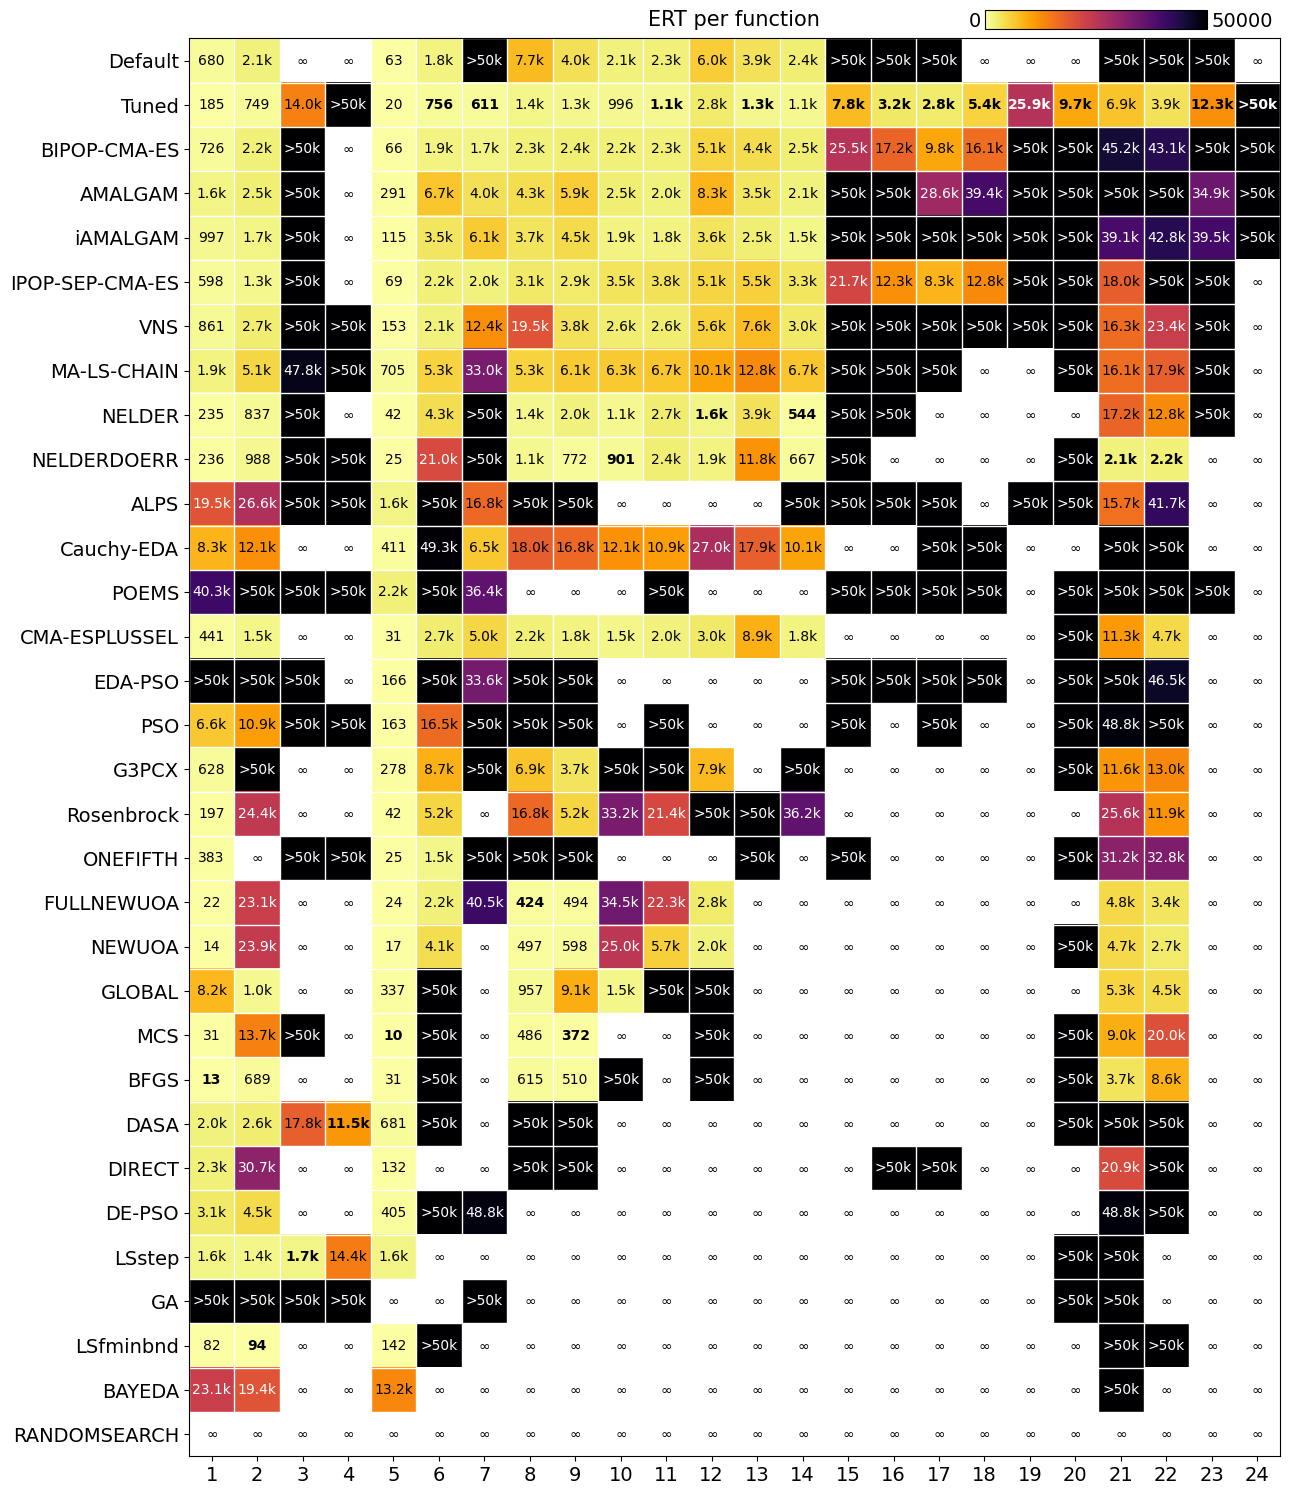

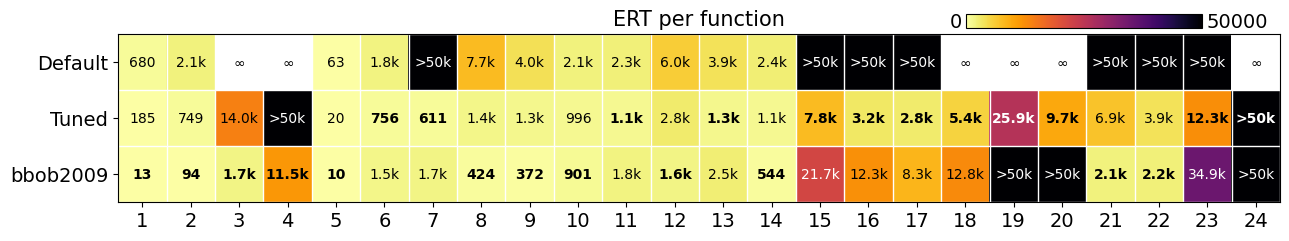

In [12]:
def fmt(value):
    if value == np.inf:
        return "$\\infty$"
    if value > 10_000 * 5:
        return ">50k"
    if np.log10(value) > 3:
        return f"{value/1000:.1f}k"
    return f"{int(value):d}"


f, ax = plot_heatmap(pd.concat([ert_table, dt_ert_bbob]), fmt=fmt, vmax=10_000 * 5, cmap='inferno_r', fmtsize=10, minimize=True)
ax.set_title("ERT per function", y=1.003, fontsize=15)
plt.savefig("ert_heatmap_all.pdf");

ert_table.loc['bbob2009'] = bbob2009_ert.tolist()
f, ax = plot_heatmap(ert_table, fmt=fmt, vmax=10_000 * 5, cmap='inferno_r', fmtsize=10, minimize=True)
ax.set_title("ERT per function", y=1.003, fontsize=15)
plt.savefig("ert_heatmap_small.pdf");

In [ ]:



cat_cols = [x for x in configs_all.columns[11:] if "0" not in x]

from catboost import CatBoostRegressor
import shap
from sklearn.model_selection import train_test_split


def get_dataset(fid, records):
    df = records.query(f"fid == {fid}")
    X = df[cat_cols].astype("category")
    y = df["cost"].values
    return X, y

X, y = get_dataset(1, configs_all)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

min_corrs = []
for depth in (6, 8, 10, 12, 14):
    models = []
    shap_list = []
    importances = []
    scores = []
    for seed in (0, 1, 2, 3, 4):
        model = CatBoostRegressor(
            iterations=2000,
            learning_rate=0.03,
            depth=depth,
            loss_function="RMSE",
            l2_leaf_reg=10,
            random_strength=2,
            bagging_temperature=1,
            random_seed=seed,
            early_stopping_rounds=100,
            verbose=100,
        )
        model.fit(X_train, y_train, cat_features=cat_cols)
        models.append(model)
        scores.append(model.score(X_val, y_val))

        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X)
        shap_list.append(shap_values)
        imp = np.mean(np.abs(shap_values), axis=0)
        importances.append(imp)

    importances = pd.DataFrame(np.array(importances))
    importances.T.corr()
    min_corrs.append((depth, np.mean(scores), importances.T.corr().min().min()))
print(min_corrs)

0:	learn: 0.3568896	total: 13ms	remaining: 26s
100:	learn: 0.2868085	total: 946ms	remaining: 17.8s
200:	learn: 0.2612553	total: 1.94s	remaining: 17.4s
300:	learn: 0.2465050	total: 2.94s	remaining: 16.6s
400:	learn: 0.2363766	total: 4.01s	remaining: 16s
500:	learn: 0.2267233	total: 5.03s	remaining: 15.1s
600:	learn: 0.2203729	total: 6.05s	remaining: 14.1s
700:	learn: 0.2159755	total: 7.14s	remaining: 13.2s
800:	learn: 0.2120564	total: 8.24s	remaining: 12.3s
900:	learn: 0.2086977	total: 9.38s	remaining: 11.4s
1000:	learn: 0.2054453	total: 10.5s	remaining: 10.5s
1100:	learn: 0.2026824	total: 11.7s	remaining: 9.55s
1200:	learn: 0.2002031	total: 12.9s	remaining: 8.61s
1300:	learn: 0.1978895	total: 14.2s	remaining: 7.61s
1400:	learn: 0.1956358	total: 15.4s	remaining: 6.59s
1500:	learn: 0.1933432	total: 16.7s	remaining: 5.56s
1600:	learn: 0.1911491	total: 18.1s	remaining: 4.5s
1700:	learn: 0.1890685	total: 19.4s	remaining: 3.41s
1800:	learn: 0.1870335	total: 20.8s	remaining: 2.3s
1900:	learn:

In [ ]:
shap_list_f = []
for fid in range(1, 25):
    print(fid, end=', ', flush=True)
    X, y = get_dataset(fid, configs_all)
    model = CatBoostRegressor(
        iterations=2000,
        learning_rate=0.03,
        depth=10,
        loss_function="RMSE",
        l2_leaf_reg=10,
        random_strength=2,
        bagging_temperature=1,
        random_seed=69,
        early_stopping_rounds=100,
        verbose=100,
    )

    model.fit(X, y, cat_features=cat_cols)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    shap_list_f.append(shap_values)

    # shap.plots.beeswarm(
    #     explainer(X), # Do I need this, think I call it twice now
    #     show=False,
    #     max_display=20,
    # )

    break
print("done")


1, 0:	learn: 0.3560251	total: 345ms	remaining: 11m 30s
100:	learn: 0.2413023	total: 3.08s	remaining: 57.9s
200:	learn: 0.1955351	total: 5.96s	remaining: 53.3s
300:	learn: 0.1727237	total: 8.81s	remaining: 49.7s
400:	learn: 0.1587148	total: 11.5s	remaining: 45.8s
500:	learn: 0.1483450	total: 14.3s	remaining: 42.8s
600:	learn: 0.1416278	total: 17.1s	remaining: 39.9s
700:	learn: 0.1366891	total: 20.3s	remaining: 37.6s
800:	learn: 0.1318392	total: 23.5s	remaining: 35.2s
900:	learn: 0.1273443	total: 26.6s	remaining: 32.4s
1000:	learn: 0.1235287	total: 30.2s	remaining: 30.1s
1100:	learn: 0.1198019	total: 33.6s	remaining: 27.4s
1200:	learn: 0.1166358	total: 36.8s	remaining: 24.4s
1300:	learn: 0.1135297	total: 40.5s	remaining: 21.8s
1400:	learn: 0.1108069	total: 44.4s	remaining: 19s
1500:	learn: 0.1084549	total: 47.7s	remaining: 15.8s
1600:	learn: 0.1064713	total: 50.7s	remaining: 12.6s
1700:	learn: 0.1048554	total: 53.8s	remaining: 9.45s
1800:	learn: 0.1031902	total: 56.9s	remaining: 6.28s
19

In [132]:
dfs = []
for i, fid in enumerate(range(1, 25)):
    confs = configs_all.query(f"fid == {fid}")
    df = pd.DataFrame(shap_list_f[i], columns=cat_cols)
    df.index = confs.index
    assert len(df) == len(confs)
    dfs.append(df)

df_shap = pd.concat(dfs)
dt = df_shap.merge(configs_all, left_index=True, right_index=True, how='outer', suffixes=("_shap", ""))

/tmp/ipykernel_1298/2128667702.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


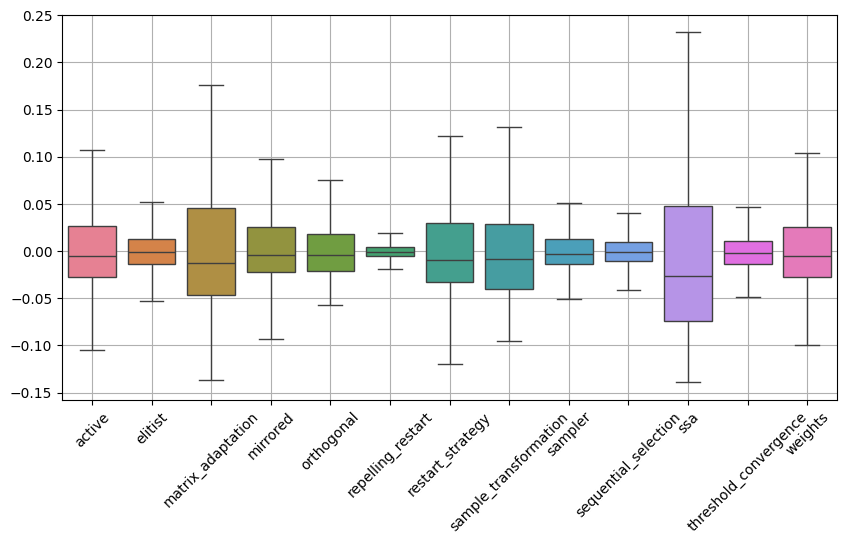

In [144]:
import seaborn as sns
f, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(dfs[0], showfliers=False, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.grid()

In [157]:
dt.columns

shap_cols = [c for c in dt.columns if c.endswith('_shap')]
cat_cols = [c.replace('_shap', '') for c in shap_cols]

non_cat_cols = [c for c in dt.columns if c not in shap_cols + cat_cols]

dfs = []

for cat, shap in zip(cat_cols, shap_cols):
    tmp = dt[non_cat_cols].copy()
    tmp["module"] = cat               
    tmp["option"] = dt[cat]           
    tmp["shap"] = dt[shap]  
    tmp['mag'] = abs(dt[shap])   
    dfs.append(tmp)

shap_df = pd.concat(dfs, ignore_index=True)
shap_df
# df_shap.abs().median(axis=0).plot.bar()

,fid,iid,dim,target,final_y,evals,hit_target,precision,cid,cost,time,lambda0,mu0,cat_name,cat_value,metric
0,1,7,5,-1000.00,-1000.000000,744,True,3.731998e-09,1,0.006717,0.033325,8,4,active,False,-0.013127
1,1,2,5,394.48,394.480000,688,True,8.386849e-09,1,0.006659,0.031963,8,4,active,False,-0.013127
2,1,7,5,-1000.00,-999.999236,49978,False,7.637566e-04,2,0.548058,0.652770,35,1,active,False,-0.053990
3,1,2,5,394.48,394.488778,49986,False,8.777582e-03,2,0.681271,0.602579,35,1,active,False,-0.053990
4,1,6,5,-201.72,-201.720000,664,True,8.164534e-09,1,0.006584,0.030669,8,4,active,False,-0.013127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31199995,24,2,5,93.30,121.392087,50067,False,2.809209e+01,4011,0.946970,0.102335,1,1,weights,DEFAULT,0.000904
31199996,24,4,5,194.80,213.657624,50106,False,1.885762e+01,4011,0.930622,0.102219,1,1,weights,DEFAULT,0.000904
31199997,24,5,5,-133.59,-110.831751,50002,False,2.275825e+01,4011,0.947264,0.109259,1,1,weights,DEFAULT,0.000904
31199998,24,7,5,-288.33,-269.000028,49999,False,1.932997e+01,4011,0.944331,0.100380,1,1,weights,DEFAULT,0.000904


In [266]:
plot_df = (
    shap_df
    .groupby(["module", "option"], as_index=False)
    .agg(shap=("shap", "median"), err=("shap", "std"))
    .sort_values(["module", "shap"], ascending=[True, False])
)

# unique plotting key, visible label stays just the option
plot_df["x_key"] = plot_df["module"].astype(str) + "___" + plot_df["option"].astype(str)
plot_df["option_label"] = plot_df["option"].astype(str)

/tmp/ipykernel_1298/1299242937.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df["option_label"], rotation=45, ha="right")


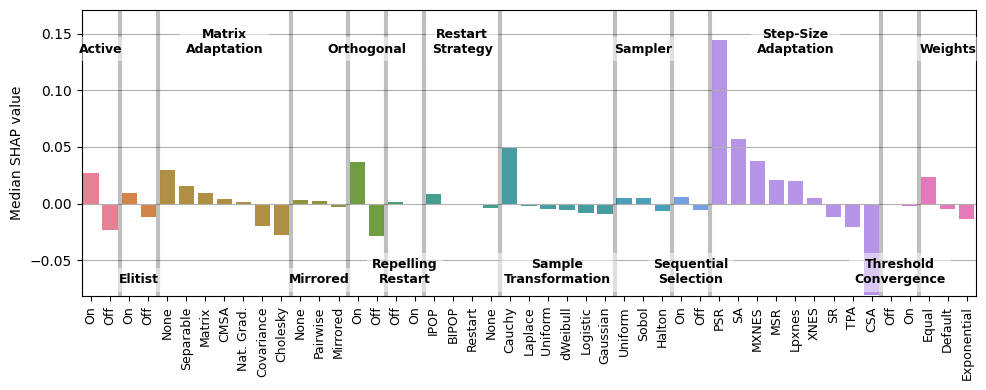

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

sns.barplot(
    data=plot_df,
    x="x_key",
    y="shap",
    hue="module",
    # palette="Set3",
    ax=ax,
    legend=False,
)

# replace unique x labels with readable option labels
ax.set_xticklabels(plot_df["option_label"], rotation=45, ha="right")

# dividers + module labels
ymax = plot_df["shap"].max()
ymin = plot_df["shap"].min()
ax.set_ylim(ymin *1.01, ymax * 1.18)

module_groups = plot_df.groupby("module", sort=False).size()

start = 0
for i, (module, n) in enumerate(module_groups.items()):
    end = start + n - 1
    center = (start + end) / 2
    if module == "ssa":
        module = "Step-size_Adaptation"
    pos = (ymax if i % 2 == 0 else ymin) * .9
    ax.text(
        center,
        pos,
        # ymax * .9 + (.015 * (i % 2)),
        module.replace("_", "\n").title(),
        ha="center",
        va="bottom",
        fontsize=9,
        # rotation=45,
        fontweight="bold",
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
    )

    if i < len(module_groups) - 1:
        ax.axvline(end + 0.5, color="black", linewidth=3, alpha=0.25)

    start += n

ax.grid(axis="y")
ax.set_xlabel(None)
ax.set_ylabel("Median SHAP value")

def make_label(s):
    if s == "True":
        return "On"
    elif s == "False":
        return "Off"
    if len(s) < 6 and s not in ("NONE", "SOBOL", "EQUAL"):
        return s
    
    if s == "NATURAL_GRADIENT":
        return "Nat. Grad."
    
    if s == "DOUBLE_WEIBULL":
        return "dWeibull"
    
    return s.replace('_', ' ').title().replace("Scaled","")
labels = [label.get_text() for label in ax.get_xticklabels()]
labels = [make_label(l) for l in labels]
ticks = ax.get_xticks()
ax.set_xticks(ticks, labels, fontsize=9, ha="center", va="top", rotation=90)
ax.tick_params(axis='x')
plt.tight_layout()
plt.savefig("median_shap.pdf")

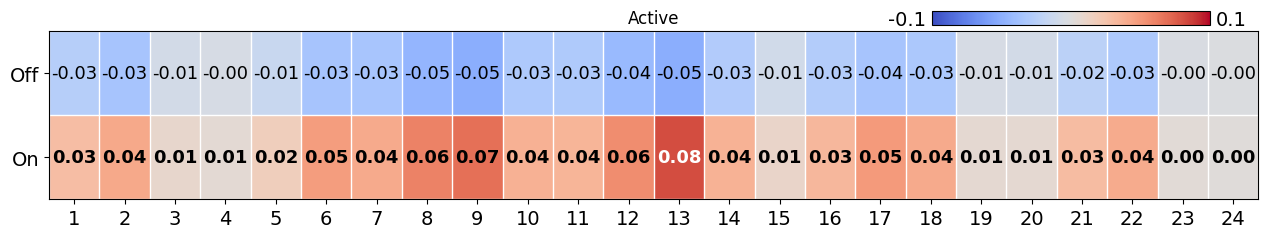

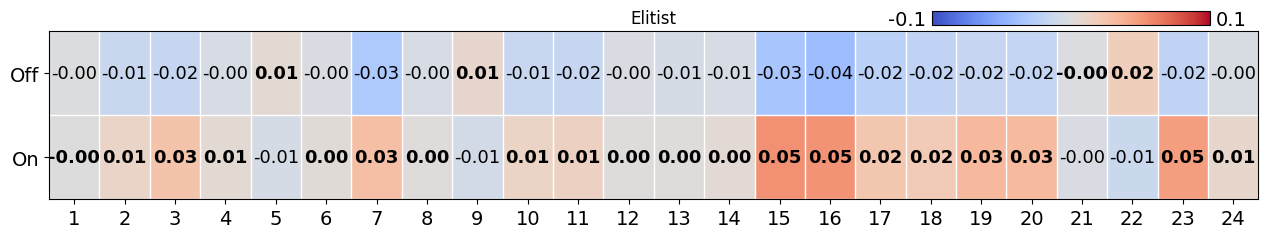

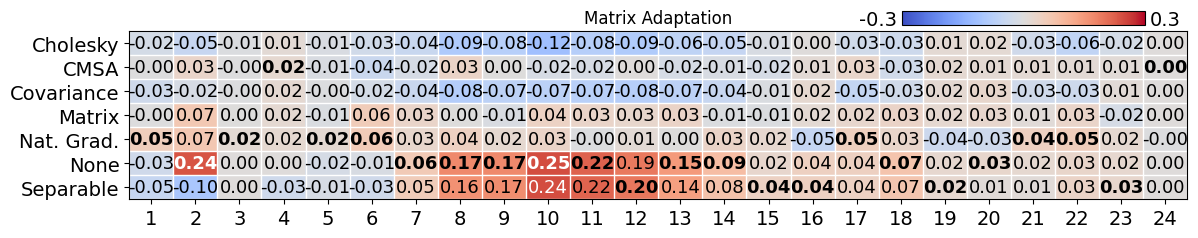

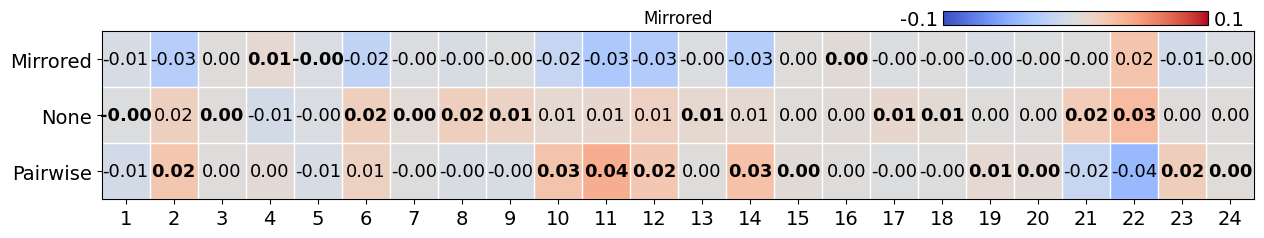

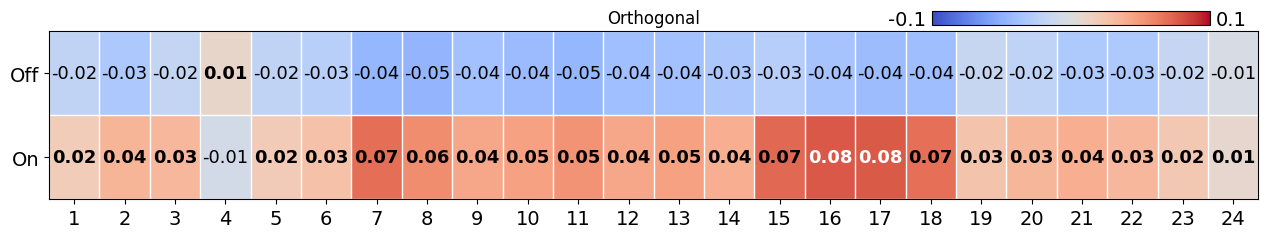

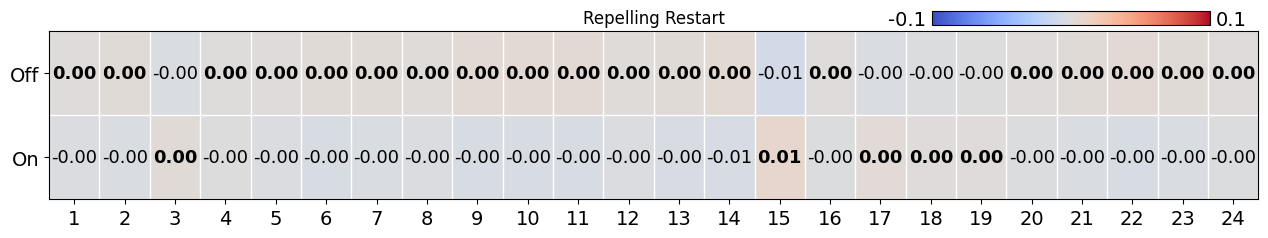

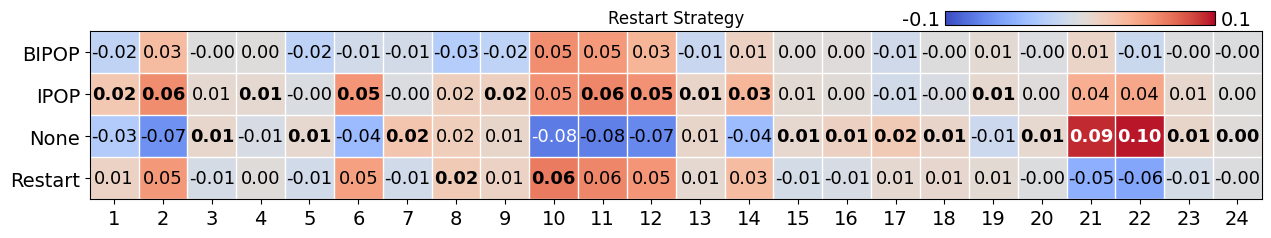

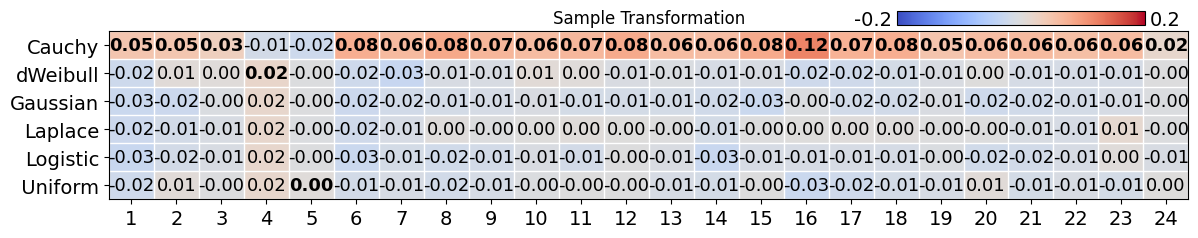

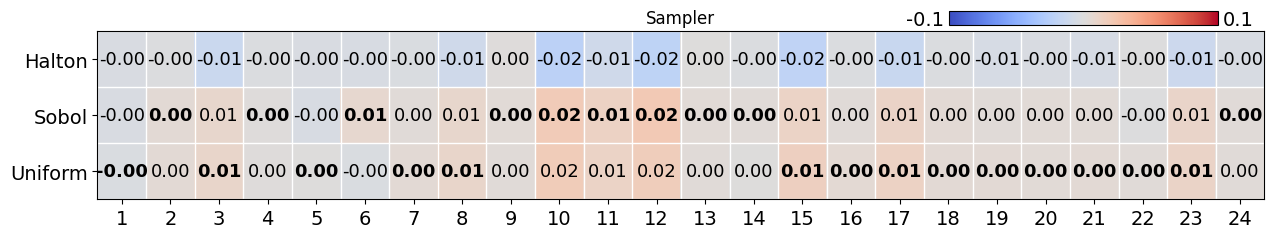

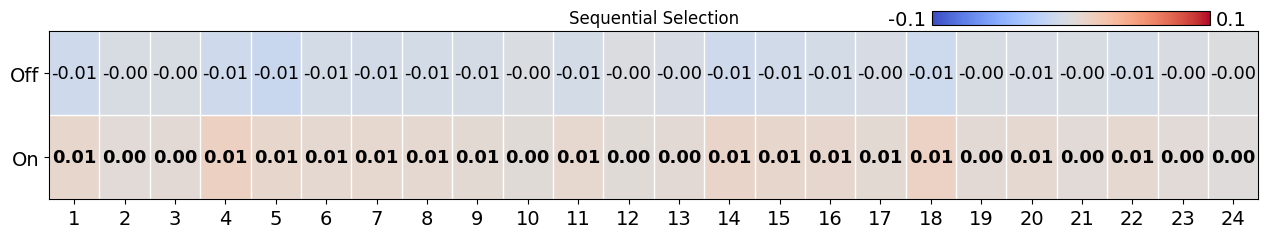

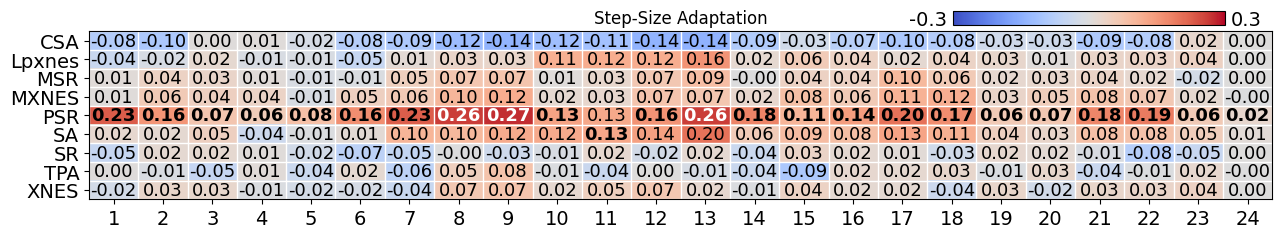

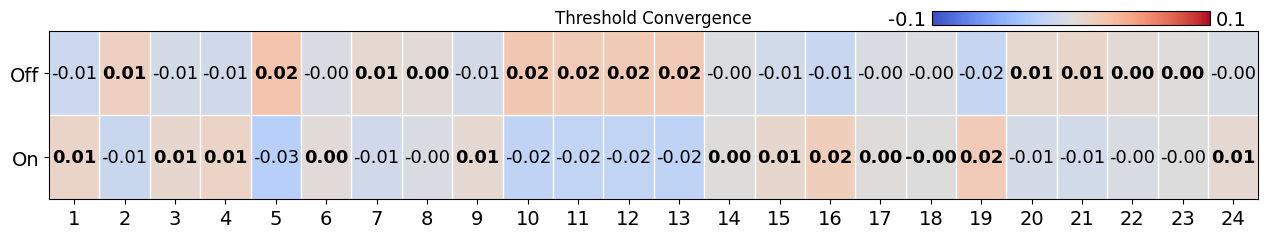

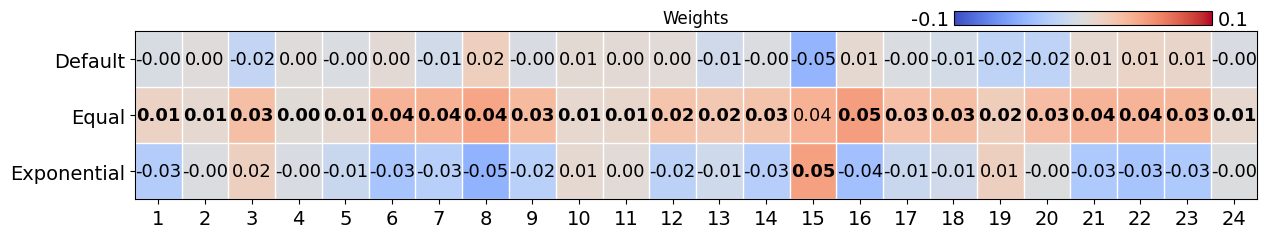

In [332]:
for module in cat_cols:
    shm = shap_df.query(f"module == '{module}'").pivot_table(index="fid", columns="option", values="shap", aggfunc="median").T
    vm = np.ceil(max(abs(shm.min().min()), shm.max().max()) * 10) / 10
    f, ax = plot_heatmap(shm, vmin=-vm, vmax=vm, cmap='coolwarm')
    
    name = module.replace("_", " ").title()
    if name == "Ssa":
        name = "Step-Size Adaptation"

    labels = [label.get_text() for label in ax.get_yticklabels()]
    labels = [make_label(l) for l in labels]
    ticks = ax.get_yticks()
    ax.set_yticks(ticks, labels)
    ax.set_title(name, y=1.0)
    plt.savefig(f"{module}_shap_heat.pdf")

np.float64(0.05)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'active'),
  Text(1, 0, 'elitist'),
  Text(2, 0, 'matrix_adaptation'),
  Text(3, 0, 'mirrored'),
  Text(4, 0, 'orthogonal'),
  Text(5, 0, 'repelling_restart'),
  Text(6, 0, 'restart_strategy'),
  Text(7, 0, 'sample_transformation'),
  Text(8, 0, 'sampler'),
  Text(9, 0, 'sequential_selection'),
  Text(10, 0, 'ssa'),
  Text(11, 0, 'threshold_convergence'),
  Text(12, 0, 'weights')])

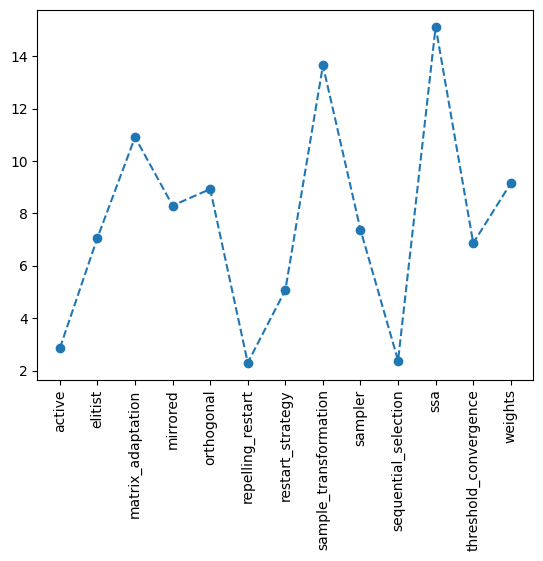

In [317]:
plt.plot(cat_cols, model.feature_importances_, linestyle='dashed', marker='o')
plt.xticks(rotation=90)